# Analyse python - Bank Marketing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

print("outils importes")

outils importes


In [2]:
df = pd.read_csv('bank-full.csv', sep=';')
print(df.shape)

(45211, 17)


In [3]:
#voir les premieres lignes
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# nom des colonnes
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [5]:
# valeurs manquante 
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [6]:
#statistique general
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [7]:
# combien ont souscrit
df['y'].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [8]:
# taux de souscription
taux = df['y'].value_counts(normalize=True) * 100
print(round(taux, 1))

y
no     88.3
yes    11.7
Name: proportion, dtype: float64


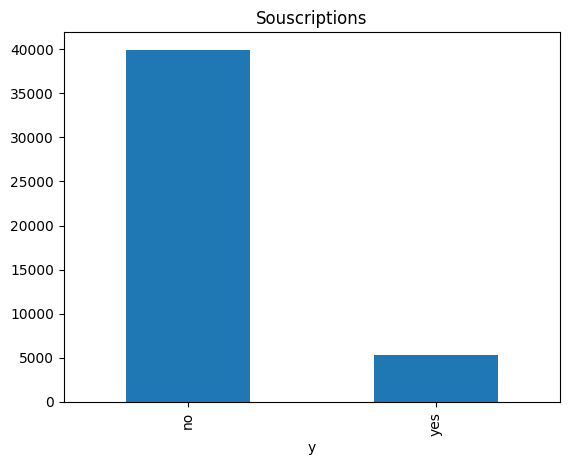

In [9]:
# graphique souscriptions
df['y'].value_counts().plot(kind='bar')
plt.title('Souscriptions')
plt.show()

In [10]:
# taux de souscription par metier
total = df.groupby('job')['y'].count()
souscrit = df[df['y'] == 'yes'].groupby('job')['y'].count()
taux_metier = (souscrit / total * 100).round(1)
print(taux_metier.sort_values(ascending=False))

job
student          28.7
retired          22.8
unemployed       15.5
management       13.8
admin.           12.2
unknown          11.8
self-employed    11.8
technician       11.1
services          8.9
housemaid         8.8
entrepreneur      8.3
blue-collar       7.3
Name: y, dtype: float64


In [11]:
# taux de souscription par mois
total = df.groupby('month')['y'].count()
souscrit = df[df['y'] == 'yes'].groupby('month')['y'].count()
taux_mois = (souscrit / total * 100).round(1)
print(taux_mois.sort_values(ascending=False))

month
mar    52.0
dec    46.7
sep    46.5
oct    43.8
apr    19.7
feb    16.6
aug    11.0
jun    10.2
nov    10.2
jan    10.1
jul     9.1
may     6.7
Name: y, dtype: float64


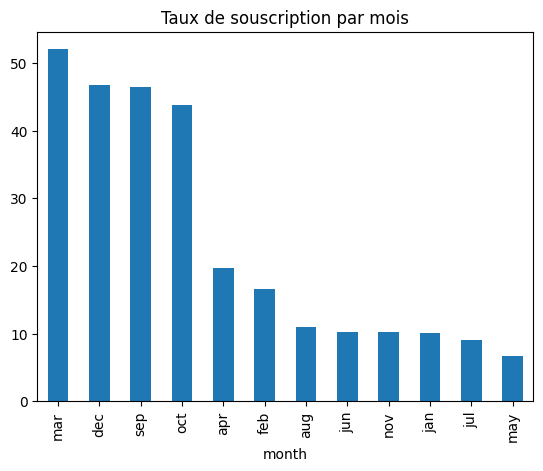

In [12]:
# graphique taux par mois
taux_mois.sort_values(ascending=False).plot(kind='bar')
plt.title('Taux de souscription par mois')
plt.show()

In [13]:
# solde moyen selon souscription
solde_moyen = df.groupby('y')['balance'].mean().round(0)
print(solde_moyen)

y
no     1304.0
yes    1804.0
Name: balance, dtype: float64


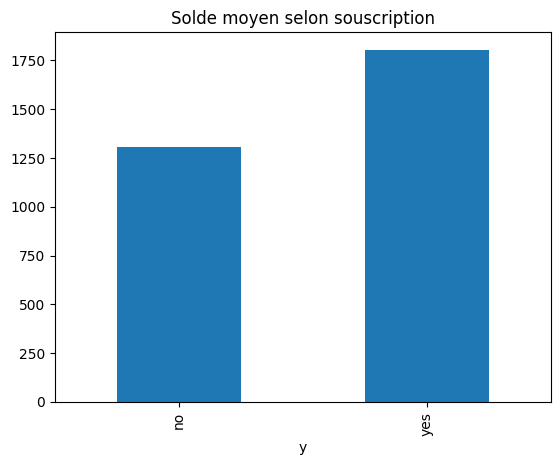

In [14]:
# graphique solde moyen
solde_moyen.plot(kind='bar')
plt.title('Solde moyen selon souscription')
plt.show()

In [16]:
# sauvegarder les donnees nettoyees
df.to_csv('bank_debutant.csv', index=False)
print("fichier sauvegarde")

fichier sauvegarde
